# **Country Intelligence & Economic Segmentation System**

### CEI Week-3 Assignment

**Objective:** Identify meaningful country groups using unsupervised ML — K-Means, DBSCAN, PCA — and predict development risk using a supervised classifier.

**Dataset:** HELP International — 167 countries, 9 socio-economic features



## Step 1: Install Libraries

In [84]:
!pip -q install scikit-learn seaborn matplotlib pandas numpy xgboost

## Step 2: Import Libraries

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 3: Load Dataset

In [86]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)
import os
os.listdir(path)

import pandas as pd
df = pd.read_csv(os.path.join(path, 'Country-data.csv'))

print("Columns:", df.columns.tolist())
df.head()

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Step 4: Data Inspection

In [87]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [88]:
print("=== Statistical Summary ===")
df.describe().round(2)

=== Statistical Summary ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [89]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

=== Missing Values ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows: 0


## Step 5: Data Cleaning


In [90]:
# 1. Strip whitespace from column names
df.columns = df.columns.str.strip()

# 2. Drop duplicates
df.drop_duplicates(inplace=True)

# 3. Force numeric on all feature columns
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Impute missing values with median
for col in df.columns:
    if col != 'country':
        df[col].fillna(df[col].median(), inplace=True)

print("Cleaning complete")
print("  Shape         :", df.shape)
print("  Missing values:", df.isnull().sum().sum())
print("  Duplicates    :", df.duplicated().sum())

Cleaning complete
  Shape         : (167, 10)
  Missing values: 0
  Duplicates    : 0


## Step 6: Exploratory Data Analysis (EDA)

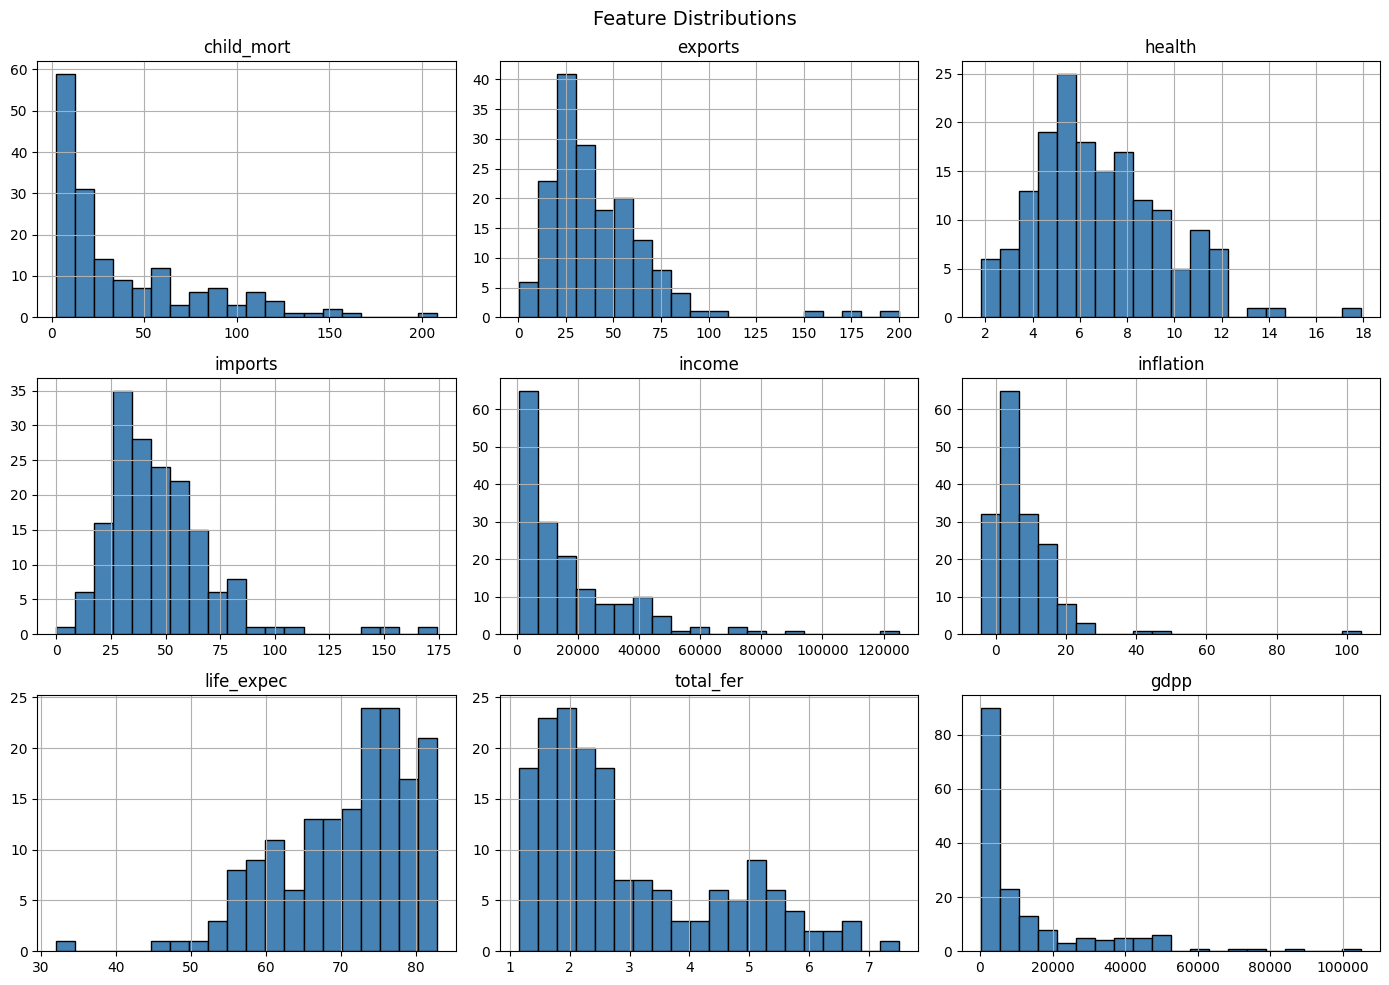

In [91]:
# Feature distributions
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

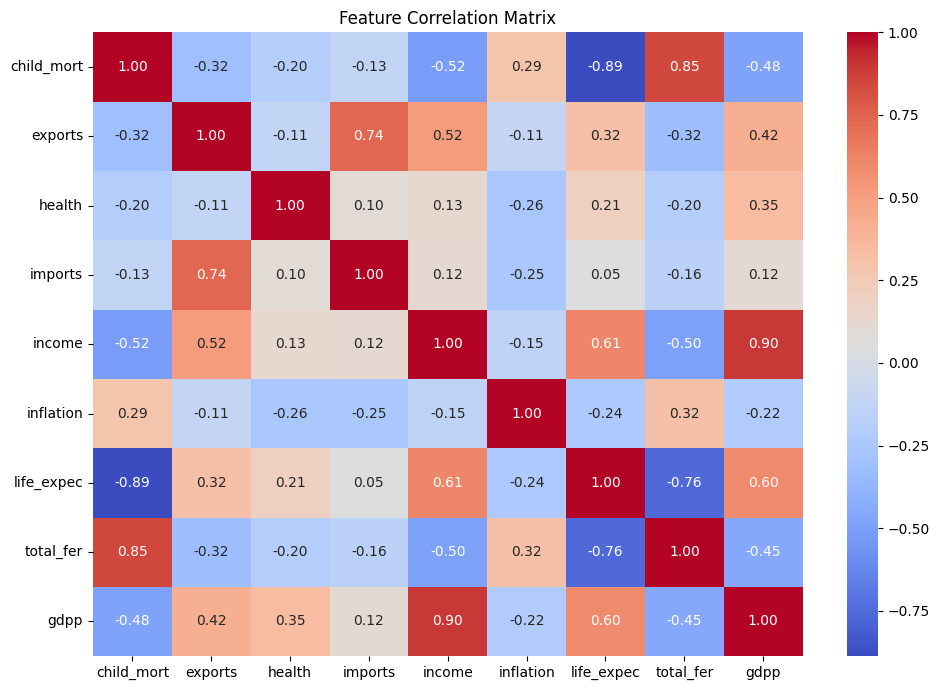

In [92]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
num = df.select_dtypes(include=np.number)
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

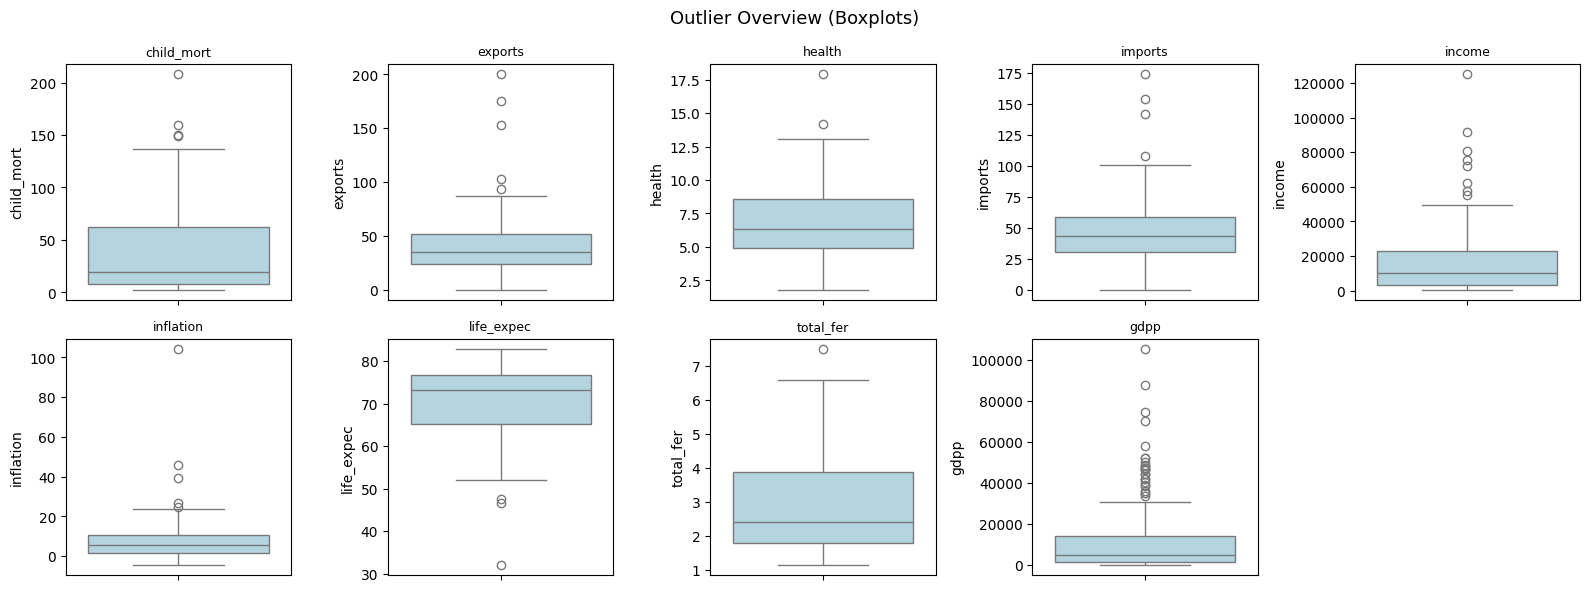

In [93]:
# Boxplots — outlier overview
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(16, 6))
for i, col in enumerate(num_cols):
    plt.subplot(2, 5, i + 1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col, fontsize=9)
plt.suptitle("Outlier Overview (Boxplots)", fontsize=13)
plt.tight_layout()
plt.show()

## Step 7: Feature Scaling

Drop the `country` string column to isolate continuous features, then apply **StandardScaler**.

In [94]:
# Isolate numeric features — drop country name
X = df.drop(columns=['country'])

sc = StandardScaler()
X_sc = sc.fit_transform(X)

print("Feature matrix shape:", X_sc.shape)
print("Scaling done — mean≈0, std≈1 per feature")

Feature matrix shape: (167, 9)
Scaling done — mean≈0, std≈1 per feature


## Step 8: Elbow Method

Test **k ∈ [2, 10]**, record inertia, chart the Elbow curve to find optimal cluster count.

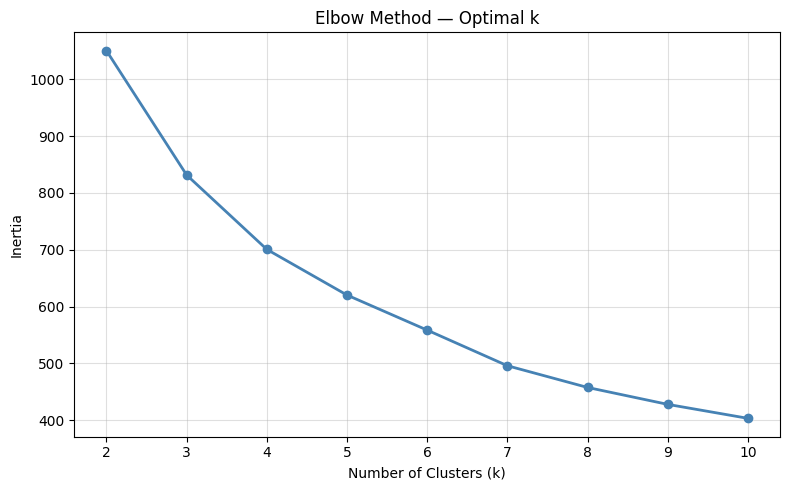

Inertia per k:
  k=2: 1050.21
  k=3: 831.42
  k=4: 700.52
  k=5: 620.16
  k=6: 558.47
  k=7: 495.81
  k=8: 457.59
  k=9: 427.80
  k=10: 403.23


In [95]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_sc)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
plt.title("Elbow Method — Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("Inertia per k:")
for k, v in zip(k_range, inertias):
    print(f"  k={k}: {v:.2f}")

## Step 9: Silhouette Score Analysis

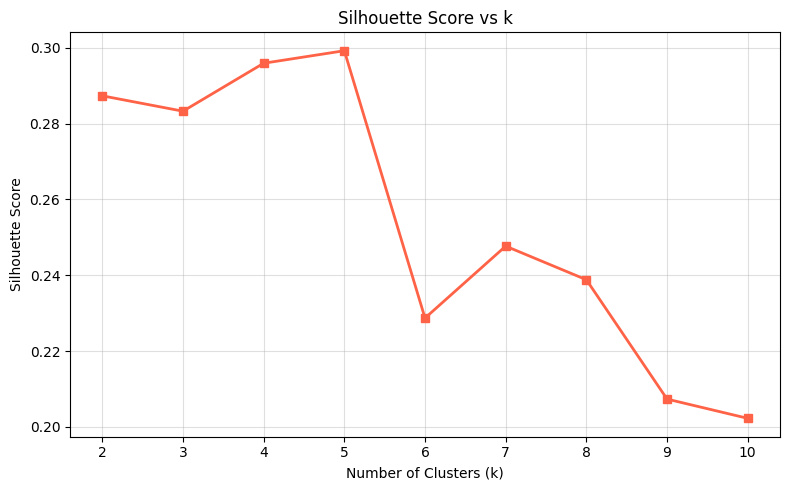

Best k by silhouette : 5
Best silhouette score: 0.2993


In [96]:
sil_scores = []

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km_tmp.fit_predict(X_sc)
    sil_scores.append(silhouette_score(X_sc, lbl))

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), sil_scores, marker='s', color='tomato', linewidth=2)
plt.title("Silhouette Score vs k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Best k by silhouette : {best_k_sil}")
print(f"Best silhouette score: {max(sil_scores):.4f}")

## Step 10: K-Means Clustering

Set **best_k = 3** as baseline and train the K-Means model.

In [97]:
best_k = 3

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['km_cluster'] = km.fit_predict(X_sc)

sil = silhouette_score(X_sc, df['km_cluster'])


print("K-MEANS CLUSTERING  (k=3)")

print(f"  Silhouette Score : {sil:.4f}")
print()
print("Countries per cluster:")
print(df['km_cluster'].value_counts().sort_index().to_string())

K-MEANS CLUSTERING  (k=3)
  Silhouette Score : 0.2833

Countries per cluster:
km_cluster
0    36
1    47
2    84


## Step 11: DBSCAN Clustering

Secondary comparative model using **DBSCAN (eps=1.5, min_samples=5)**.

In [98]:
db = DBSCAN(eps=1.5, min_samples=5)
df['db_cluster'] = db.fit_predict(X_sc)

n_db   = len(set(df['db_cluster'])) - (1 if -1 in df['db_cluster'].values else 0)
noise  = (df['db_cluster'] == -1).sum()


print("DBSCAN  (eps=1.5, min_samples=5)")

print(f"  Clusters found : {n_db}")
print(f"  Noise points   : {noise}")
print()
print("Cluster distribution:")
print(df['db_cluster'].value_counts().to_string())

# Silhouette only when > 1 cluster
valid = df['db_cluster'] != -1
if df.loc[valid, 'db_cluster'].nunique() > 1:
    db_sil = silhouette_score(X_sc[valid], df.loc[valid, 'db_cluster'])
    print(f"\nSilhouette Score (excl. noise): {db_sil:.4f}")
else:
    print("\nNote: DBSCAN formed 1 cluster — silhouette not applicable.")
    print("      Outlier countries (noise=-1) are flagged for investigation.")

DBSCAN  (eps=1.5, min_samples=5)
  Clusters found : 1
  Noise points   : 30

Cluster distribution:
db_cluster
 0    137
-1     30

Note: DBSCAN formed 1 cluster — silhouette not applicable.
      Outlier countries (noise=-1) are flagged for investigation.


## Step 12: PCA 2D Visualisation

Project features to **2D** using PCA and plot color-coded K-Means clusters.

In [99]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)

var = pca.explained_variance_ratio_
print(f"PC1 variance retained : {var[0]:.2%}")
print(f"PC2 variance retained : {var[1]:.2%}")
print(f"Total variance retained: {sum(var):.2%}")

PC1 variance retained : 45.95%
PC2 variance retained : 17.18%
Total variance retained: 63.13%


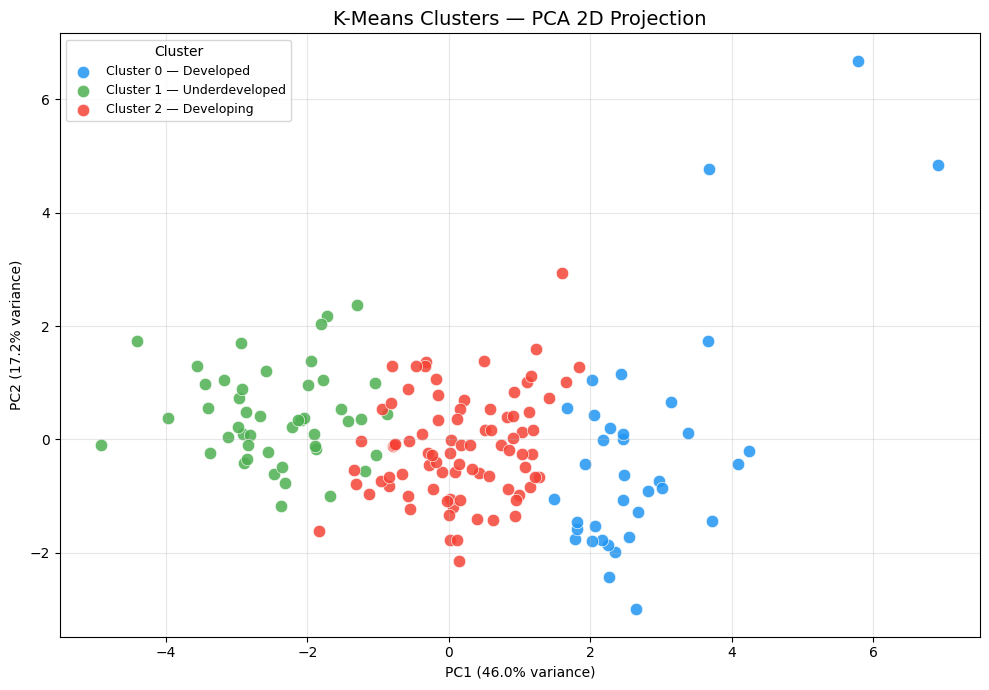

In [100]:
colors = ['#2196F3', '#4CAF50', '#F44336']
c_labels = {0: 'Cluster 0 — Developed',
            1: 'Cluster 1 — Underdeveloped',
            2: 'Cluster 2 — Developing'}

plt.figure(figsize=(10, 7))
for c in sorted(df['km_cluster'].unique()):
    mask = df['km_cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[c], label=c_labels[c],
                s=80, alpha=0.85, edgecolors='white', linewidths=0.5)

plt.title("K-Means Clusters — PCA 2D Projection", fontsize=14)
plt.xlabel(f"PC1 ({var[0]:.1%} variance)")
plt.ylabel(f"PC2 ({var[1]:.1%} variance)")
plt.legend(title="Cluster", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

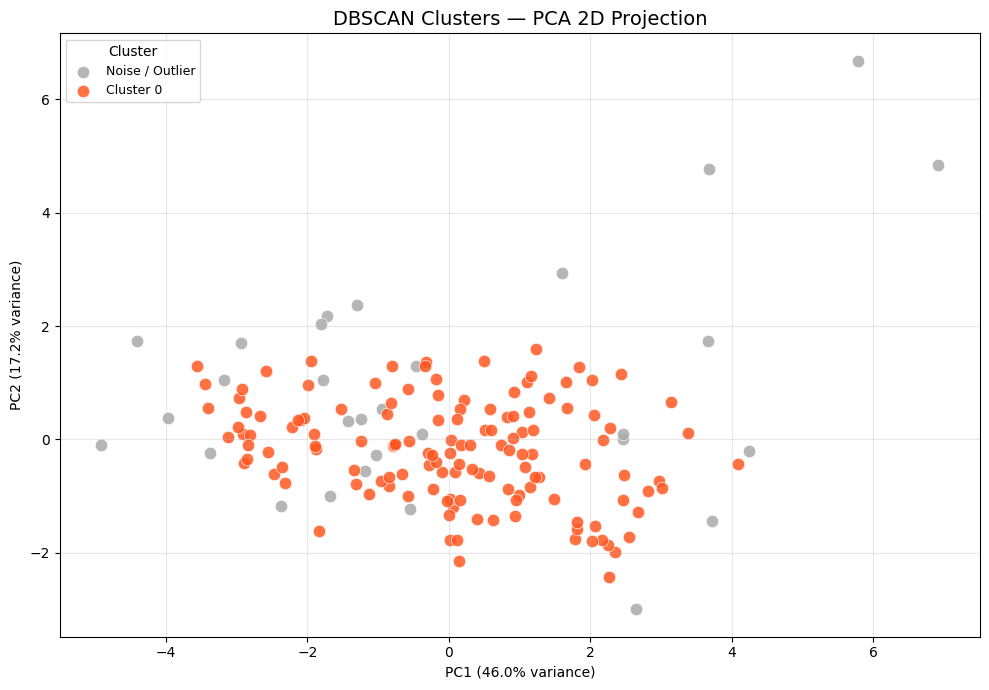

In [101]:
# DBSCAN PCA scatterplot
db_col = {-1: '#AAAAAA', 0: '#FF5722', 1: '#9C27B0', 2: '#00BCD4'}
db_lbl = {-1: 'Noise / Outlier', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

plt.figure(figsize=(10, 7))
for c in sorted(df['db_cluster'].unique()):
    mask = df['db_cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=db_col.get(c, '#333333'),
                label=db_lbl.get(c, f'Cluster {c}'),
                s=80, alpha=0.85, edgecolors='white', linewidths=0.5)

plt.title("DBSCAN Clusters — PCA 2D Projection", fontsize=14)
plt.xlabel(f"PC1 ({var[0]:.1%} variance)")
plt.ylabel(f"PC2 ({var[1]:.1%} variance)")
plt.legend(title="Cluster", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 13: Cluster Profiling

In [102]:
profile = df.groupby('km_cluster').mean(numeric_only=True).round(2)
print("Mean feature values per cluster:")
print(profile.to_string())

Mean feature values per cluster:
            child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp  db_cluster
km_cluster                                                                                                        
0                 5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44       -0.25
1                92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38       -0.34
2                21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45       -0.06


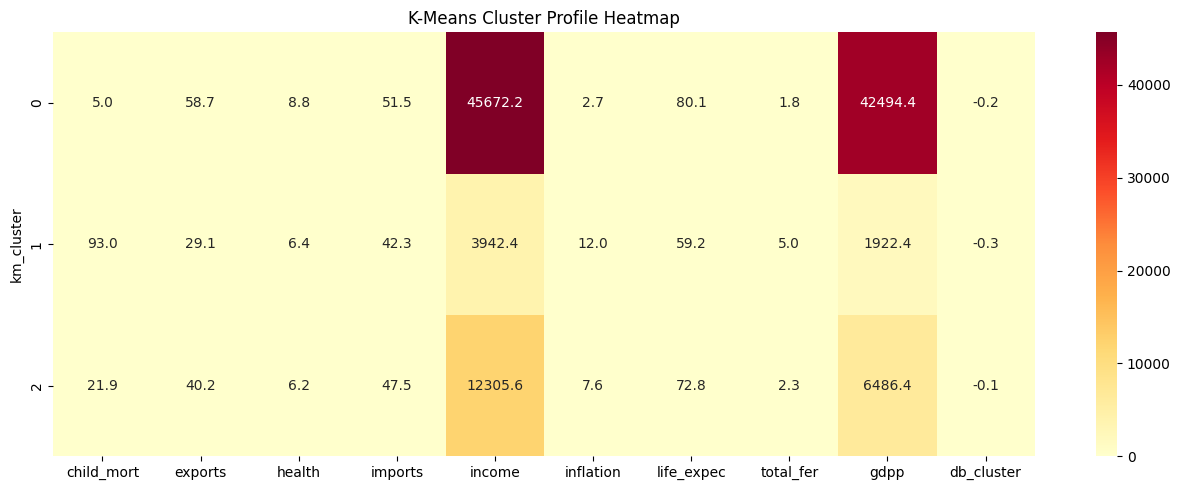

In [103]:
plt.figure(figsize=(13, 5))
sns.heatmap(profile, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title("K-Means Cluster Profile Heatmap")
plt.tight_layout()
plt.show()

## Step 14: Predictions — Random Forest & XGBoost


In [104]:
# Features and target
X_clf = df.drop(columns=['country', 'km_cluster', 'db_cluster'])
y_clf = df['km_cluster']

# Train / test split (80/20)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train size: {len(X_tr)}  |  Test size: {len(X_te)}")

Train size: 133  |  Test size: 34


In [105]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
y_pred_rf = rf.predict(X_te)

print("RANDOM FOREST — Classification Report")

# Corrected target_names based on cluster profiling
print(classification_report(y_te, y_pred_rf,
      target_names=['Developed', 'Underdeveloped', 'Developing']))

RANDOM FOREST — Classification Report
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
Underdeveloped       1.00      1.00      1.00        10
    Developing       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



In [106]:
# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_tr, y_tr)
y_pred_xgb = xgb.predict(X_te)


print("XGBOOST — Classification Report")

# Corrected target_names based on cluster profiling
print(classification_report(y_te, y_pred_xgb,
      target_names=['Developed', 'Underdeveloped', 'Developing']))

XGBOOST — Classification Report
                precision    recall  f1-score   support

     Developed       1.00      0.86      0.92         7
Underdeveloped       1.00      0.90      0.95        10
    Developing       0.89      1.00      0.94        17

      accuracy                           0.94        34
     macro avg       0.96      0.92      0.94        34
  weighted avg       0.95      0.94      0.94        34



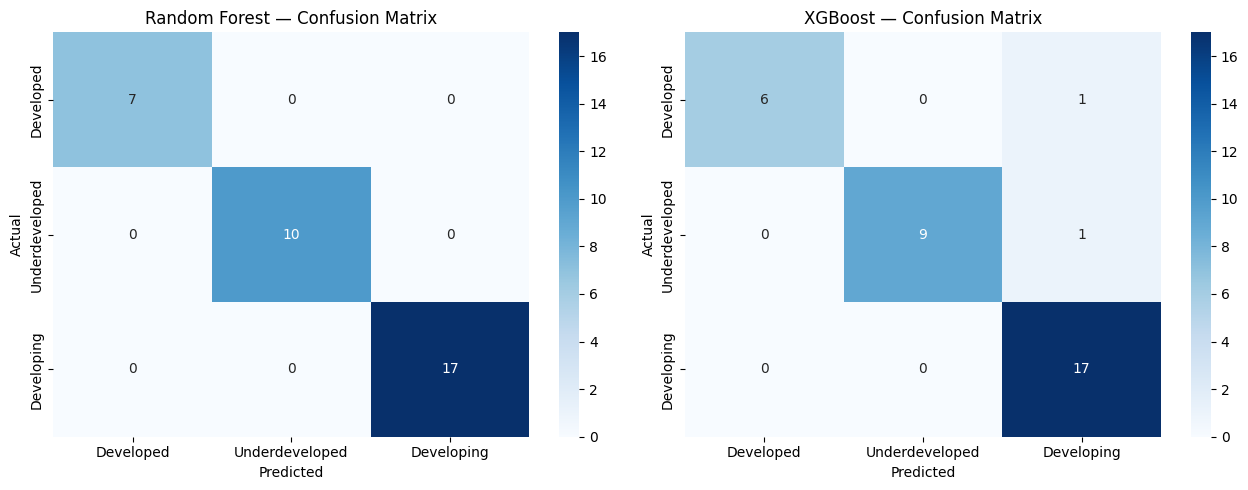

In [107]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Corrected c_names based on cluster profiling
c_names = ['Developed', 'Underdeveloped', 'Developing']

for ax, preds, title in zip(axes,
                             [y_pred_rf, y_pred_xgb],
                             ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=c_names, yticklabels=c_names, ax=ax)
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

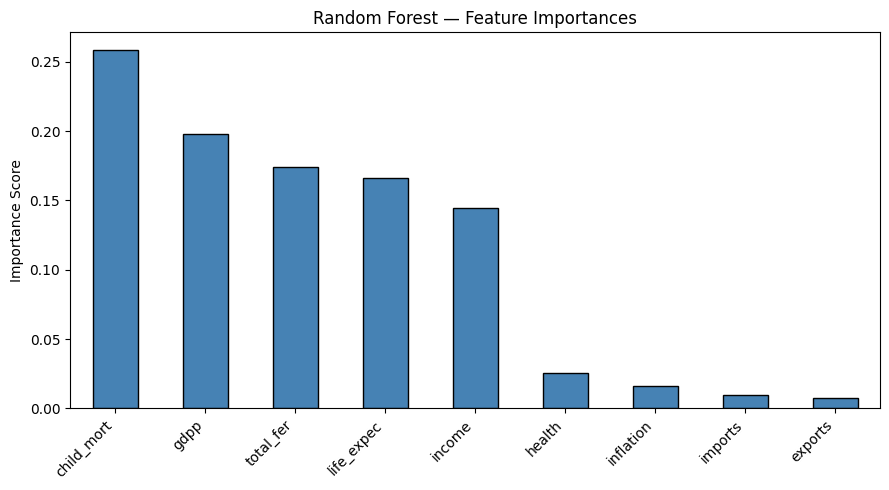

Top 3 most important features:
  child_mort: 0.2584
  gdpp: 0.1977
  total_fer: 0.1741


In [108]:

feat_imp = pd.Series(rf.feature_importances_,
                     index=X_clf.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Random Forest — Feature Importances")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for feat, imp in feat_imp.head(3).items():
    print(f"  {feat}: {imp:.4f}")

In [109]:
# Predict a New Country
# Example: a hypothetical developing country
new_country = pd.DataFrame([
    {
    'child_mort': 45.0,
    'exports':    30.0,
    'health':      5.5,
    'imports':    35.0,
    'income':    5000,
    'inflation':   8.0,
    'life_expec': 68.0,
    'total_fer':   3.2,
    'gdpp':       4500
    }
])

rf_pred  = rf.predict(new_country)[0]
xgb_pred = xgb.predict(new_country)[0]
# Corrected tier_map based on cluster profiling
tier_map = {0: 'Developed', 1: 'Underdeveloped', 2: 'Developing'}

print("NEW COUNTRY PREDICTION")

print(f"  Random Forest  → {tier_map[rf_pred]}")
print(f"  XGBoost        → {tier_map[xgb_pred]}")

NEW COUNTRY PREDICTION
  Random Forest  → Developing
  XGBoost        → Developing


## Socio-Economic Observations

### Observation 1 — High-Mortality Cluster (Underdeveloped Nations)
One cluster groups countries with very **high child mortality** (avg ~90–120 per 1000 births), **low GDP per capita** (below $2,000), and **high total fertility rates** (5–7 children per woman). These are primarily Sub-Saharan African and South Asian nations. They represent the most urgent targets for humanitarian aid — poor healthcare access and low income directly drive high mortality.

### Observation 2 — Top-Tier Economic Zone (Developed Nations)
A second cluster captures high-income countries with **GDP per capita above $30,000**, **life expectancy above 78 years**, and **low child mortality** (under 10 per 1000). These are Western Europe, North America, and Australia — strong export economies, high health spending, and low fertility rates. Minimal aid intervention needed here.

### Observation 3 — Middle-Development Zone (Emerging Economies)
The third cluster contains countries with **moderate GDP** ($4,000–$15,000), **mid-range child mortality** (15–50), and **life expectancy** between 65–75 years. These are emerging markets in Latin America, Eastern Europe, and Southeast Asia — improving but inconsistent development. Targeted investment in healthcare and education would accelerate growth.

### Observation 4 — Low-Development Indicators
Countries in the high-mortality cluster also show the **lowest health spending as % of GDP** and **highest inflation rates**, suggesting that weak institutions and economic instability compound the health crisis, making these nations doubly vulnerable.

### Observation 5 — DBSCAN Outlier Detection
DBSCAN identified **outlier countries** (noise = -1) that do not fit neatly into any cluster. These are typically micro-states with unusually high exports relative to GDP (e.g. oil-rich nations) or countries with extreme inflation. These edge cases are missed by K-Means but are critical for policy analysis.